# Spatial rainfall partial correlation controlled for IOD

This notebook plots the spatial partial correlation of rainfall with Niño 3.4 after controlling for the Indian Ocean Dipole (IOD/DMI). It compares P1 (1981–2006), P2 (2007–2025), and their difference.

Run the notebook with `Scripts/Supplement` as the working directory. The only required input is the copied NetCDF cache in `data/`.

In [1]:
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from scipy.ndimage import gaussian_filter

# ===== TEXT-SIZE CONTROLS =====
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 24,
    'axes.labelsize': 24,
    'axes.titlesize': 24,
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
    'figure.dpi': 150,
})

# Run this notebook with Scripts/Supplement as the working directory.
SUPPLEMENT_DIR = Path('/Users/rizzie/Work/PaperENSO/Scripts_v2/Supplement/PartialCorrIOD')
DATA_DIR = SUPPLEMENT_DIR if not (SUPPLEMENT_DIR / 'data').exists() else (SUPPLEMENT_DIR / 'data')
PARTIAL_CORR_CACHE = DATA_DIR / 'rainfall_partial_corr_cache_1981_2025.nc'
OUTPUT_PATH = SUPPLEMENT_DIR / 'partial_correlation_iod.png'

assert PARTIAL_CORR_CACHE.exists(), f'Missing {PARTIAL_CORR_CACHE}'

def smooth_for_plot(data, sigma=0.7):
    """Apply light spatial smoothing while preserving coordinates and attributes."""
    def smooth_array(array):
        return gaussian_filter(array, sigma=sigma)

    result = xr.apply_ufunc(
        smooth_array, data, input_core_dims=[['lat', 'lon']],
        output_core_dims=[['lat', 'lon']], vectorize=True,
        dask='allowed', output_dtypes=[data.dtype],
    )
    return result.transpose(*data.dims).assign_attrs(data.attrs)


## Load the plotted data

`rainfall_partial_corr_cache_1981_2025.nc` contains the partial-correlation maps and their significance masks.

In [2]:
rain_ds = xr.open_dataset(PARTIAL_CORR_CACHE)

rain_pcorr_p1 = rain_ds['rain_pcorr_past']
rain_pcorr_p2 = rain_ds['rain_pcorr_recent']
rain_pcorr_diff = rain_ds['rain_pcorr_recent_minus_past']

rain_pcorr_p1_sig = rain_ds['rain_pcorr_past_sig']
rain_pcorr_p2_sig = rain_ds['rain_pcorr_recent_sig']
rain_pcorr_diff_sig = rain_ds['rain_pcorr_recent_minus_past_sig']

## Create the spatial-correlation composite

The map styling and text sizing follow Figure 2. No running-correlation panel is included.

/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


...

/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


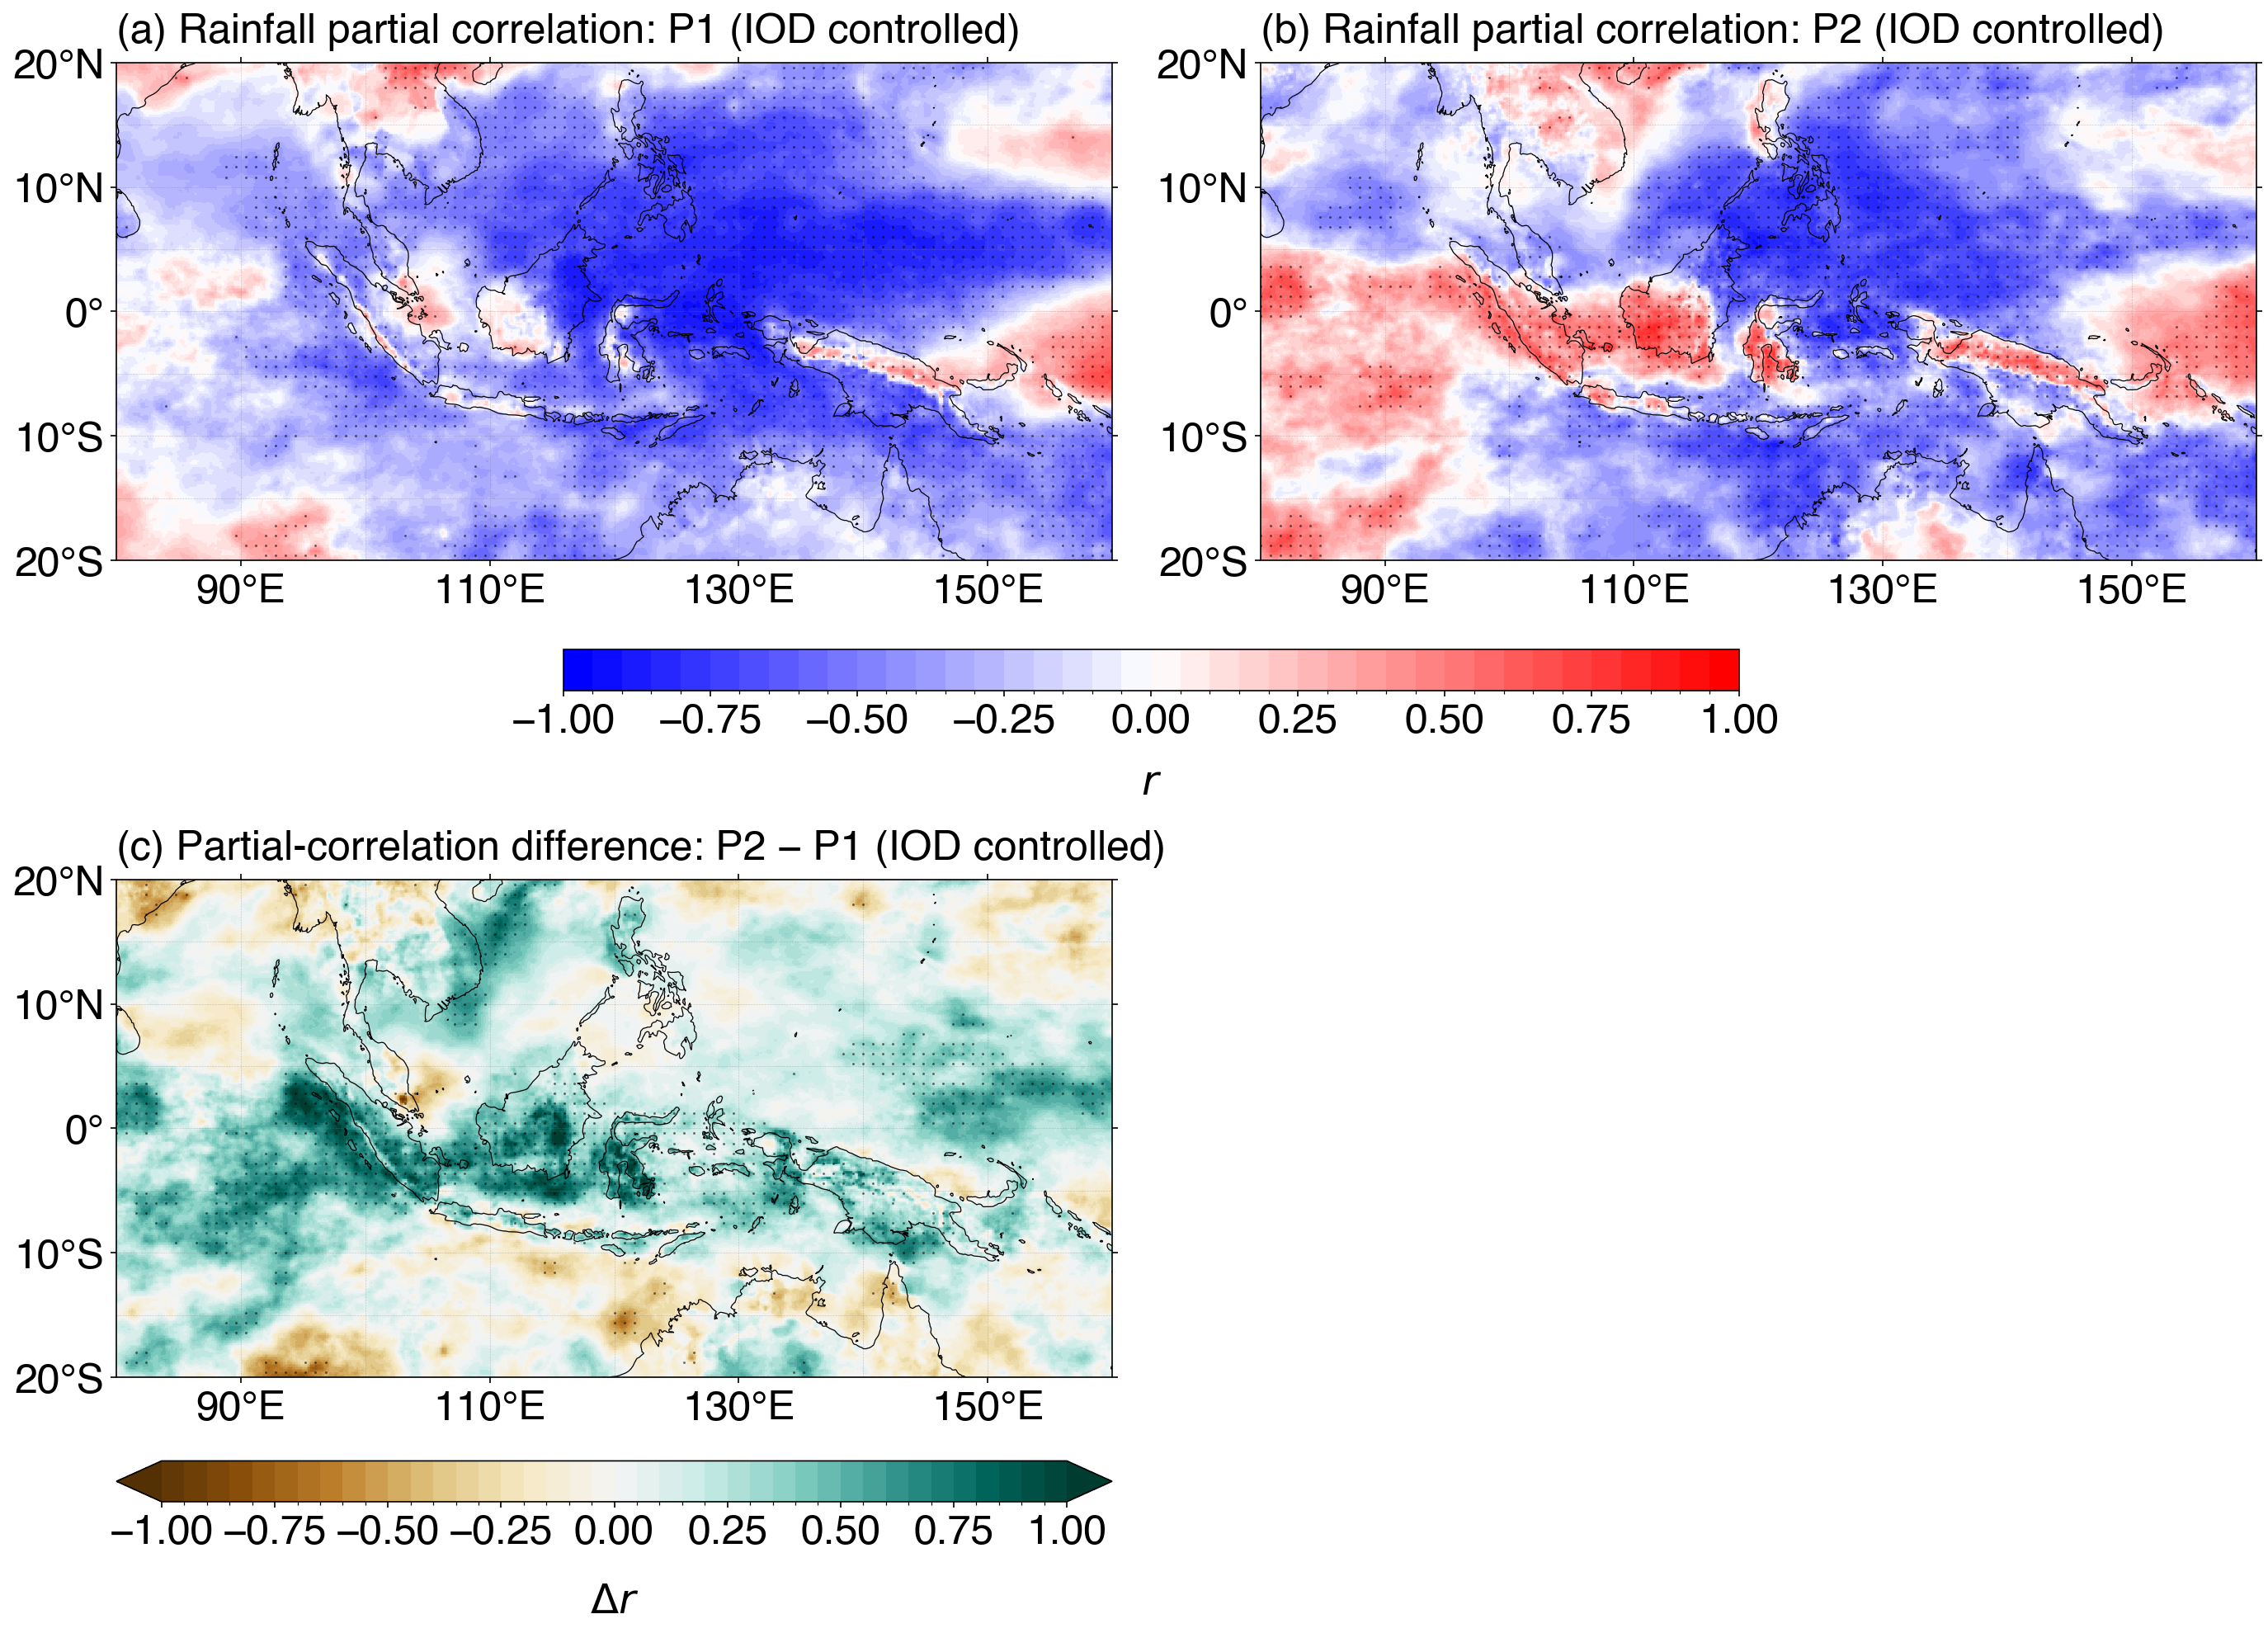

In [3]:
corr_levels = np.arange(-1, 1.01, 0.05)
corr_ticks = np.arange(-1, 1.01, 0.25)
mc_extent = [80, 160, -20, 20]
mc_xticks = np.arange(90, 161, 20)
mc_yticks = np.arange(-20, 21, 10)

fig = plt.figure(figsize=(19, 15))
gs = fig.add_gridspec(2, 4, hspace=0.1, wspace=0.35)
ax_p1 = fig.add_subplot(gs[0, 0:2], projection=ccrs.PlateCarree(central_longitude=180))
ax_p2 = fig.add_subplot(gs[0, 2:4], projection=ccrs.PlateCarree(central_longitude=180))
ax_diff = fig.add_subplot(gs[1, 0:2], projection=ccrs.PlateCarree(central_longitude=180))

map_panels = [
    (ax_p1, rain_pcorr_p1, rain_pcorr_p1_sig, '(a) Rainfall partial correlation: P1 (IOD controlled)', 'bwr', 'neither'),
    (ax_p2, rain_pcorr_p2, rain_pcorr_p2_sig, '(b) Rainfall partial correlation: P2 (IOD controlled)', 'bwr', 'neither'),
    (ax_diff, rain_pcorr_diff, rain_pcorr_diff_sig, '(c) Partial-correlation difference: P2 − P1 (IOD controlled)', 'BrBG', 'both'),
]

top_img = None
diff_img = None
for ax, data, sig_mask, title, cmap, extend in map_panels:
    img = smooth_for_plot(data).reset_coords(drop=True).plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap=cmap, levels=corr_levels,
        extend=extend, add_colorbar=False, add_labels=False, infer_intervals=True,
    )
    if ax is ax_diff:
        diff_img = img
    else:
        top_img = img

    # Coarsening keeps the significance stippling legible at figure scale.
    sig_plot = (sig_mask.fillna(False).astype(np.int8)
                .coarsen(lat=8, lon=8, boundary='trim').max() > 0)
    yy, xx = np.where(sig_plot.values)
    ax.scatter(sig_plot['lon'].values[xx], sig_plot['lat'].values[yy], s=8,
               c='k', marker='.', linewidths=0, alpha=0.55,
               transform=ccrs.PlateCarree(), zorder=4)

    ax.coastlines(resolution='50m', linewidth=0.6, color='black', zorder=3)
    ax.set_extent(mc_extent, crs=ccrs.PlateCarree())
    ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.4, linestyle='--')
    ax.set_xticks(mc_xticks, crs=ccrs.PlateCarree())
    ax.set_yticks(mc_yticks, crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter(cardinal_labels={'east': 'E', 'west': 'W'}))
    ax.yaxis.set_major_formatter(LatitudeFormatter(cardinal_labels={'north': 'N', 'south': 'S'}))
    ax.tick_params(direction='out', top=True, right=True, labelsize=24)
    ax.set_title(title, loc='left', fontweight='bold', pad=12)

fig.subplots_adjust(left=0.06, right=0.97, bottom=0.10, top=0.94)
fig.canvas.draw()
pos_p1, pos_p2, pos_diff = ax_p1.get_position(), ax_p2.get_position(), ax_diff.get_position()

# Shared P1/P2 colorbar placed between the map rows.
top_cax = fig.add_axes([0.25, pos_p1.y0 - 0.070, 0.50, 0.022])
top_cbar = fig.colorbar(top_img, cax=top_cax, orientation='horizontal', ticks=corr_ticks, extend='neither')
top_cbar.set_label(r'$\it{r}$', rotation=0, labelpad=14, fontsize=24)
top_cbar.ax.tick_params(labelsize=24)
top_cbar.ax.yaxis.set_label_position('right')

# Difference colorbar belongs directly beneath panel (c).
diff_cax = fig.add_axes([pos_diff.x0, pos_diff.y0 - 0.067, pos_diff.width, 0.022])
diff_cbar = fig.colorbar(diff_img, cax=diff_cax, orientation='horizontal', ticks=corr_ticks, extend='both')
diff_cbar.set_label(r'$\Delta r$', rotation=0, labelpad=18, fontsize=24)
diff_cbar.ax.tick_params(labelsize=24)
diff_cbar.ax.yaxis.set_label_position('right')

fig.savefig(OUTPUT_PATH, dpi=300, bbox_inches='tight')
print(f'Saved: {OUTPUT_PATH}')
plt.show()
rain_ds.close()

## Output

The completed figure is saved as `partial_correlation_iod.png` in this folder. The copied NetCDF cache in `data/` is the only required input.